In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
data = {
    "product_id": range(1, 31),

    "product_name": [
        "iPhone 15", "Samsung Galaxy S24", "OnePlus 12",
        "Redmi Note 13", "Realme 12 Pro",
        "HP Pavilion Laptop", "Dell Inspiron Laptop",
        "Lenovo IdeaPad Laptop", "ASUS VivoBook Laptop",
        "MacBook Air M2",
        "Sony Headphones", "JBL Tune 770NC",
        "Boat Rockerz 550", "Apple AirPods", "Samsung Galaxy Buds",
        "Nike Running Shoes", "Adidas Sports Shoes",
        "Puma Casual Shoes", "Skechers Walking Shoes",
        "Reebok Training Shoes",
        "Canon Camera", "Sony Alpha Camera",
        "Nikon DSLR Camera", "Fujifilm Camera",
        "GoPro Action Camera",
        "Mi Smart TV", "Samsung Smart TV",
        "LG OLED TV", "Sony Bravia TV",
        "OnePlus Smart TV"
    ],

    "category": [
        "Mobile", "Mobile", "Mobile", "Mobile", "Mobile",
        "Laptop", "Laptop", "Laptop", "Laptop", "Laptop",
        "Headphones", "Headphones", "Headphones", "Headphones", "Headphones",
        "Shoes", "Shoes", "Shoes", "Shoes", "Shoes",
        "Camera", "Camera", "Camera", "Camera", "Camera",
        "Television", "Television", "Television", "Television", "Television"
    ],

    "brand": [
        "Apple", "Samsung", "OnePlus", "Redmi", "Realme",
        "HP", "Dell", "Lenovo", "ASUS", "Apple",
        "Sony", "JBL", "Boat", "Apple", "Samsung",
        "Nike", "Adidas", "Puma", "Skechers", "Reebok",
        "Canon", "Sony", "Nikon", "Fujifilm", "GoPro",
        "Mi", "Samsung", "LG", "Sony", "OnePlus"
    ],

    "price": [
        65000, 70000, 55000, 18000, 25000,
        62000, 58000, 52000, 60000, 95000,
        12000, 8000, 4500, 15000, 11000,
        7000, 6000, 5000, 6500, 5500,
        55000, 85000, 60000, 75000, 35000,
        40000, 55000, 65000, 70000, 45000
    ],

    "rating": [
        4.7, 4.6, 4.5, 4.3, 4.2,
        4.4, 4.3, 4.2, 4.4, 4.8,
        4.5, 4.4, 4.2, 4.7, 4.5,
        4.6, 4.4, 4.3, 4.5, 4.2,
        4.5, 4.7, 4.4, 4.6, 4.5,
        4.3, 4.6, 4.5, 4.7, 4.2
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Number of products:", len(df))

Dataset created successfully!
Number of products: 30


In [4]:
df.head(10)

,product_id,product_name,category,brand,price,rating
0,1,iPhone 15,Mobile,Apple,65000,4.7
1,2,Samsung Galaxy S24,Mobile,Samsung,70000,4.6
2,3,OnePlus 12,Mobile,OnePlus,55000,4.5
3,4,Redmi Note 13,Mobile,Redmi,18000,4.3
4,5,Realme 12 Pro,Mobile,Realme,25000,4.2
5,6,HP Pavilion Laptop,Laptop,HP,62000,4.4
6,7,Dell Inspiron Laptop,Laptop,Dell,58000,4.3
7,8,Lenovo IdeaPad Laptop,Laptop,Lenovo,52000,4.2
8,9,ASUS VivoBook Laptop,Laptop,ASUS,60000,4.4
9,10,MacBook Air M2,Laptop,Apple,95000,4.8


In [5]:
print(df.isnull().sum())

product_id      0
product_name    0
category        0
brand           0
price           0
rating          0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    30 non-null     int64  
 1   product_name  30 non-null     object 
 2   category      30 non-null     object 
 3   brand         30 non-null     object 
 4   price         30 non-null     int64  
 5   rating        30 non-null     float64
dtypes: float64(1), int64(2), object(3)
memory usage: 1.5+ KB


In [7]:
df.describe()

,product_id,price,rating
count,30.000000,30.000000,30.000000
mean,15.500000,40850.000000,4.456667
std,8.803408,28043.116434,0.175545
min,1.000000,4500.000000,4.200000
25%,8.250000,11250.000000,4.300000
50%,15.500000,48500.000000,4.500000
75%,22.750000,61500.000000,4.600000
max,30.000000,95000.000000,4.800000


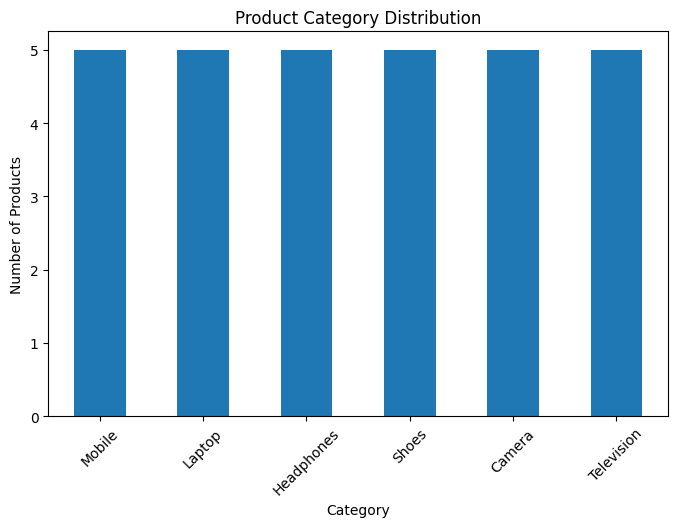

In [8]:
plt.figure(figsize=(8,5))

df["category"].value_counts().plot(kind="bar")

plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

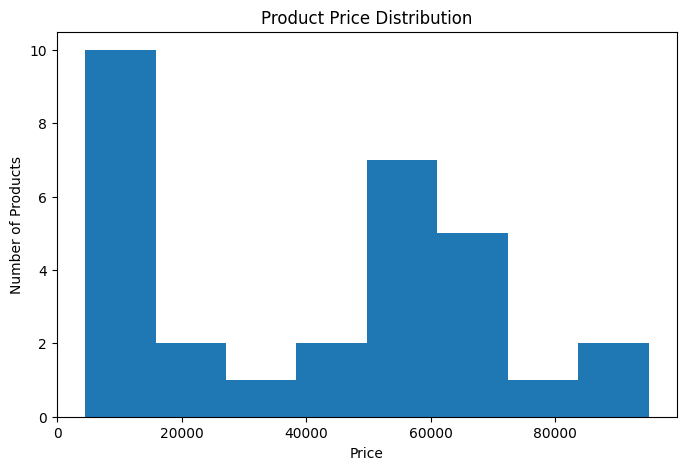

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=8)

plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.show()

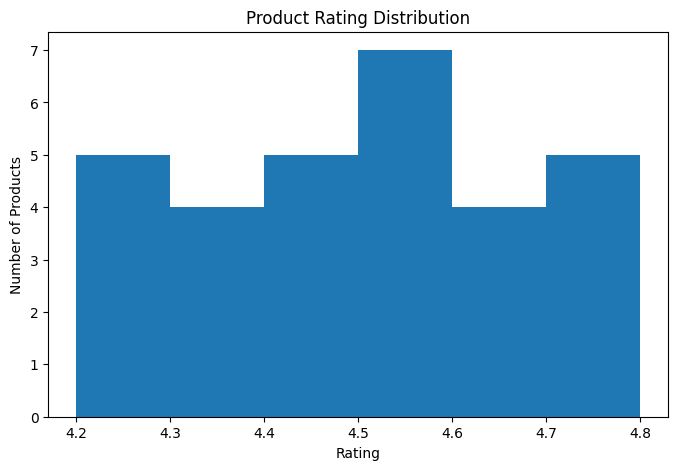

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df["rating"], bins=6)

plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.show()

In [11]:
df["features"] = (
    df["product_name"] + " " +
    df["category"] + " " +
    df["brand"]
)

df[["product_name", "features"]].head()

,product_name,features
0,iPhone 15,iPhone 15 Mobile Apple
1,Samsung Galaxy S24,Samsung Galaxy S24 Mobile Samsung
2,OnePlus 12,OnePlus 12 Mobile OnePlus
3,Redmi Note 13,Redmi Note 13 Mobile Redmi
4,Realme 12 Pro,Realme 12 Pro Mobile Realme


In [12]:
vectorizer = TfidfVectorizer(stop_words="english")

feature_matrix = vectorizer.fit_transform(df["features"])

print("Feature matrix shape:", feature_matrix.shape)

Feature matrix shape: (30, 62)


In [13]:
similarity_matrix = cosine_similarity(feature_matrix)

print("Cosine similarity calculated successfully!")
print("Similarity matrix shape:", similarity_matrix.shape)

Cosine similarity calculated successfully!
Similarity matrix shape: (30, 30)


In [14]:
def recommend_products(product_name, number_of_recommendations=5):

    if product_name not in df["product_name"].values:
        print("Product not found!")
        return

    product_index = df[df["product_name"] == product_name].index[0]

    similarity_scores = list(enumerate(similarity_matrix[product_index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommended_indices = [
        index for index, score in similarity_scores[1:number_of_recommendations+1]
    ]

    recommendations = df.iloc[recommended_indices][
        ["product_name", "category", "brand", "price", "rating"]
    ]

    return recommendations

In [15]:
recommendations = recommend_products("iPhone 15", 5)

recommendations

,product_name,category,brand,price,rating
13,Apple AirPods,Headphones,Apple,15000,4.7
9,MacBook Air M2,Laptop,Apple,95000,4.8
2,OnePlus 12,Mobile,OnePlus,55000,4.5
1,Samsung Galaxy S24,Mobile,Samsung,70000,4.6
4,Realme 12 Pro,Mobile,Realme,25000,4.2


In [16]:
def personalized_recommendation(category, max_price, min_rating=4.0):

    filtered_products = df[
        (df["category"].str.lower() == category.lower()) &
        (df["price"] <= max_price) &
        (df["rating"] >= min_rating)
    ]

    filtered_products = filtered_products.sort_values(
        by="rating",
        ascending=False
    )

    return filtered_products[
        ["product_name", "category", "brand", "price", "rating"]
    ]

In [17]:
personalized_recommendation(
    category="Mobile",
    max_price=60000,
    min_rating=4.2
)

,product_name,category,brand,price,rating
2,OnePlus 12,Mobile,OnePlus,55000,4.5
3,Redmi Note 13,Mobile,Redmi,18000,4.3
4,Realme 12 Pro,Mobile,Realme,25000,4.2


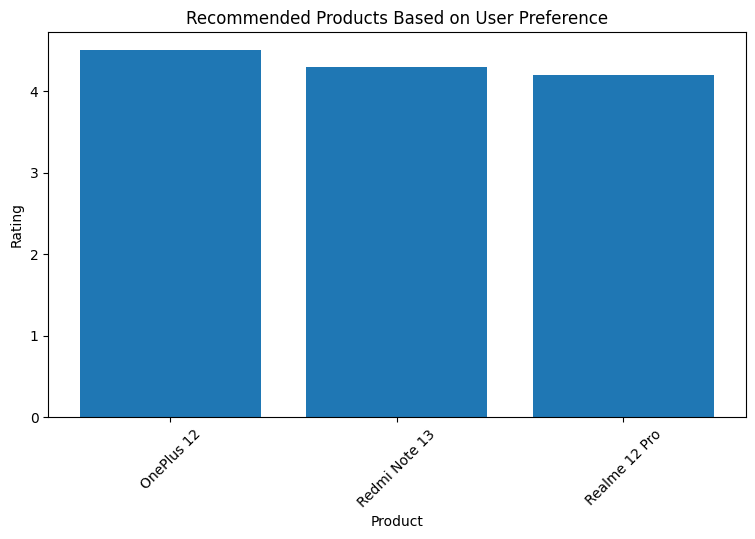

In [18]:
recommendations = personalized_recommendation(
    category="Mobile",
    max_price=60000,
    min_rating=4.2
)

plt.figure(figsize=(9,5))

plt.bar(
    recommendations["product_name"],
    recommendations["rating"]
)

plt.title("Recommended Products Based on User Preference")
plt.xlabel("Product")
plt.ylabel("Rating")

plt.xticks(rotation=45)

plt.show()

In [19]:
print("PERSONALIZED PRODUCT RECOMMENDATION")
print("------------------------------------")

category = input("Enter product category: ")
max_price = float(input("Enter maximum price: "))
min_rating = float(input("Enter minimum rating: "))

result = personalized_recommendation(
    category,
    max_price,
    min_rating
)

print("\nRecommended Products:")
print(result.to_string(index=False))

PERSONALIZED PRODUCT RECOMMENDATION
------------------------------------
Enter product category: mobile
Enter maximum price: 60000
Enter minimum rating: 4.2

Recommended Products:
 product_name category   brand  price  rating
   OnePlus 12   Mobile OnePlus  55000     4.5
Redmi Note 13   Mobile   Redmi  18000     4.3
Realme 12 Pro   Mobile  Realme  25000     4.2
